In [ ]:
import cv2
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import time
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

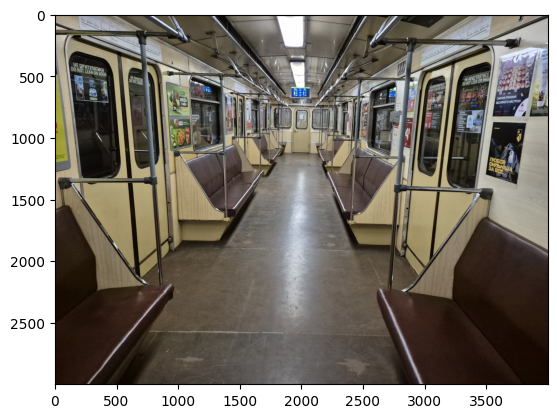

In [ ]:
img = 'img2.jpg'
img_orig = cv2.imread(img)
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
plt.imshow(img_orig)

In [ ]:
def compute_divergence(img_channel):
    gx = np.gradient(img_channel.astype(np.float64), axis=1)
    gy = np.gradient(img_channel.astype(np.float64), axis=0)
    div = np.gradient(gx, axis=1) + np.gradient(gy, axis=0)
    return div

def solve_poisson_seidel(div, boundary, max_iter=5000):
    rows, cols = div.shape
    f = boundary.copy().astype(np.float64)
    mask = (boundary == 0)

    for _ in range(max_iter):
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if mask[i, j]:
                    f[i, j] = (f[i-1, j] + f[i+1, j] + f[i, j-1] + f[i, j+1] - div[i, j]) / 4.0
    return f

In [ ]:
def solve_poisson_scipy(div, boundary):
    rows, cols = div.shape
    n = rows * cols

    def idx(i, j):
        return i * cols + j

    data, row_ids, col_ids = [], [], []
    b = np.zeros(n)

    for i in range(rows):
        for j in range(cols):
            k = idx(i, j)
            if i == 0 or i == rows-1 or j == 0 or j == cols-1:
                data.append(1.0)
                row_ids.append(k)
                col_ids.append(k)
                b[k] = boundary[i, j]
            else:
                data += [-1.0, -1.0, 4.0, -1.0, -1.0]
                row_ids += [k, k, k, k, k]
                col_ids += [idx(i-1, j), idx(i, j-1), k, idx(i, j+1), idx(i+1, j)]
                b[k] = -div[i, j]


    A = sp.csr_matrix((data, (row_ids, col_ids)), shape=(n, n))
    x = spla.spsolve(A, b)
    return x.reshape(rows, cols)

In [ ]:
def restore_image(img, method='scipy', seidel_iter=1000):
    result = np.zeros_like(img, dtype=np.float64)
    for c in range(img.shape[2]):
        channel = img[:, :, c].astype(np.float64)
        div = compute_divergence(channel)
        boundary = channel.copy()
        boundary[1:-1, 1:-1] = 0

        if method == 'seidel':
            result[:, :, c] = solve_poisson_seidel(div, boundary, max_iter=seidel_iter)
        else:
            result[:, :, c] = solve_poisson_scipy(div, boundary)

    return np.clip(result, 0, 255).astype(np.uint8)

Час: Зейдель = 4.793с | SciPy = 0.021с


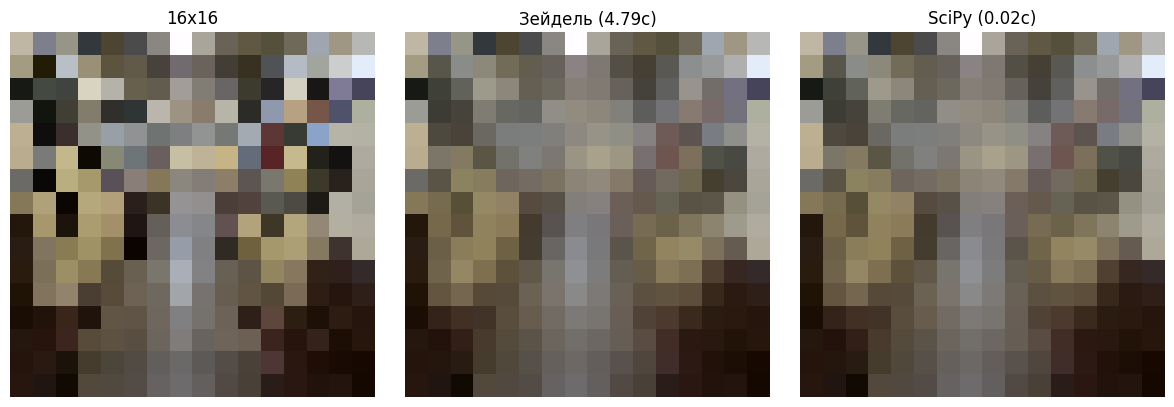

Час: Зейдель = 16.510с | SciPy = 0.021с


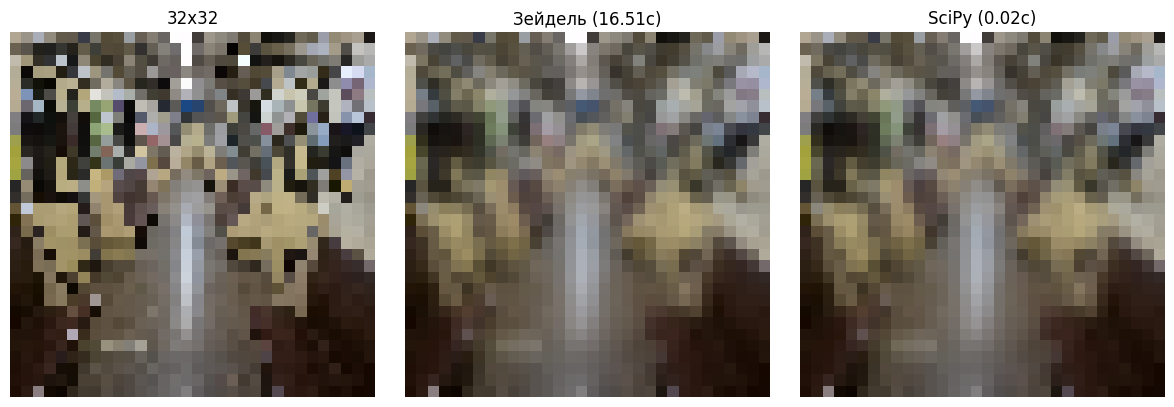

Час: Зейдель = 71.429с | SciPy = 0.076с


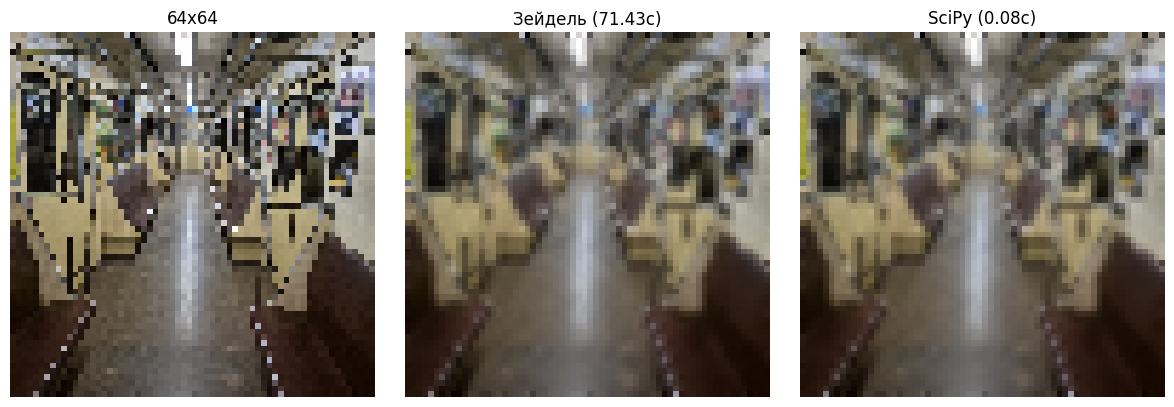

Час: Зейдель = 291.867с | SciPy = 0.402с


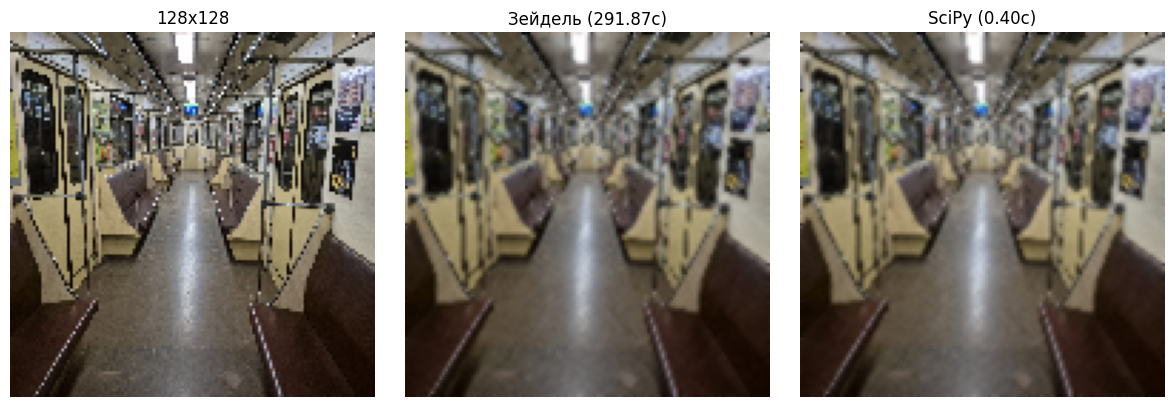

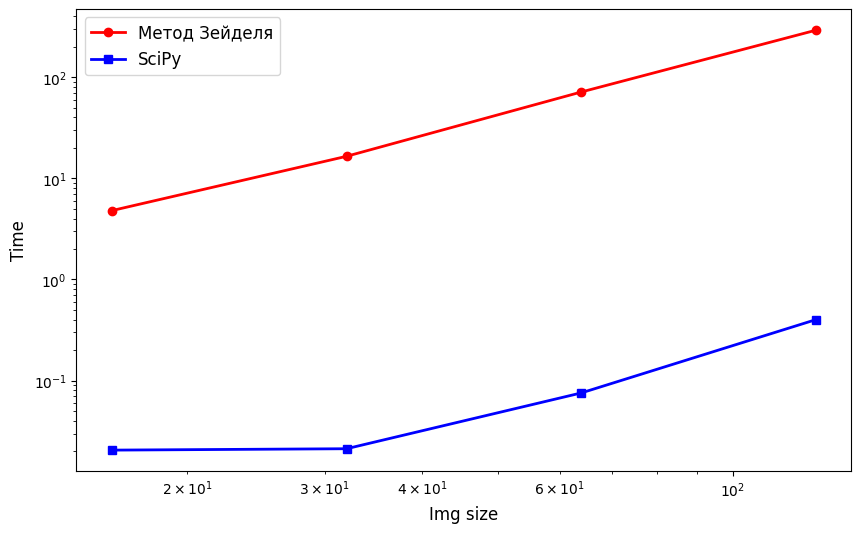

In [ ]:
sizes = [16, 32, 64, 128]
times_seidel = []
times_scipy = []


for size in sizes:
    img_test = cv2.resize(img_orig, (size, size))

    t0 = time.perf_counter()
    res_scipy = restore_image(img_test, method='scipy')
    t_scipy = time.perf_counter() - t0
    times_scipy.append(t_scipy)

    t0 = time.perf_counter()
    res_seidel = restore_image(img_test, method='seidel', seidel_iter=5000)
    t_seidel = time.perf_counter() - t0
    times_seidel.append(t_seidel)

    print(f"Час: Зейдель = {t_seidel:.3f}с | SciPy = {t_scipy:.3f}с")

    plt.figure(figsize=(12, 4))

    plt.subplot(131)
    plt.imshow(img_test)
    plt.title(f"{size}x{size}")
    plt.axis('off')

    plt.subplot(132)
    plt.imshow(res_seidel)
    plt.title(f"Зейдель ({t_seidel:.2f}c)")
    plt.axis('off')

    plt.subplot(133)
    plt.imshow(res_scipy)
    plt.title(f"SciPy ({t_scipy:.2f}c)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 6))

plt.plot(sizes, times_seidel, marker='o', color='red', linewidth=2, label='Метод Зейделя')
plt.plot(sizes, times_scipy, marker='s', color='blue', linewidth=2, label='SciPy')

plt.yscale('log')
plt.xscale('log')

plt.xlabel('Img size', fontsize=12)
plt.ylabel('Time', fontsize=12)
plt.legend(fontsize=12)

plt.show()

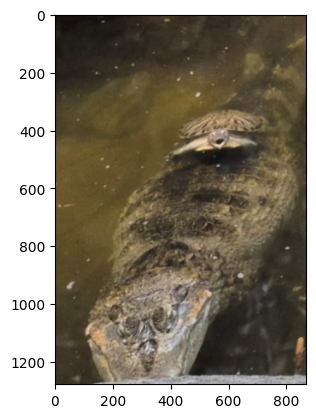

In [ ]:
blend = 'img4.jpg'
blend_orig = cv2.imread(blend)
blend_orig = cv2.cvtColor(blend_orig, cv2.COLOR_BGR2RGB)
plt.imshow(blend_orig)

In [ ]:
def seamless_clone(target, source_patch, mask_region, method='scipy', max_iter=500):
    result = target.copy().astype(np.float64)
    y1, y2, x1, x2 = mask_region

    for c in range(3):
        src_ch = source_patch[:, :, c].astype(np.float64)
        div = compute_divergence(src_ch)

        boundary = target[y1:y2, x1:x2, c].astype(np.float64)
        boundary[1:-1, 1:-1] = 0

        if method == 'scipy':
            solved = solve_poisson_scipy(div, boundary)
        else:
            solved = solve_poisson_seidel(div, boundary, max_iter=max_iter)

        result[y1:y2, x1:x2, c] = solved

    return np.clip(result, 0, 255).astype(np.uint8)

Час SciPy: 1.316 сек
Час SciPy: 1.316 сек
Час Зейделя: 606.334 сек


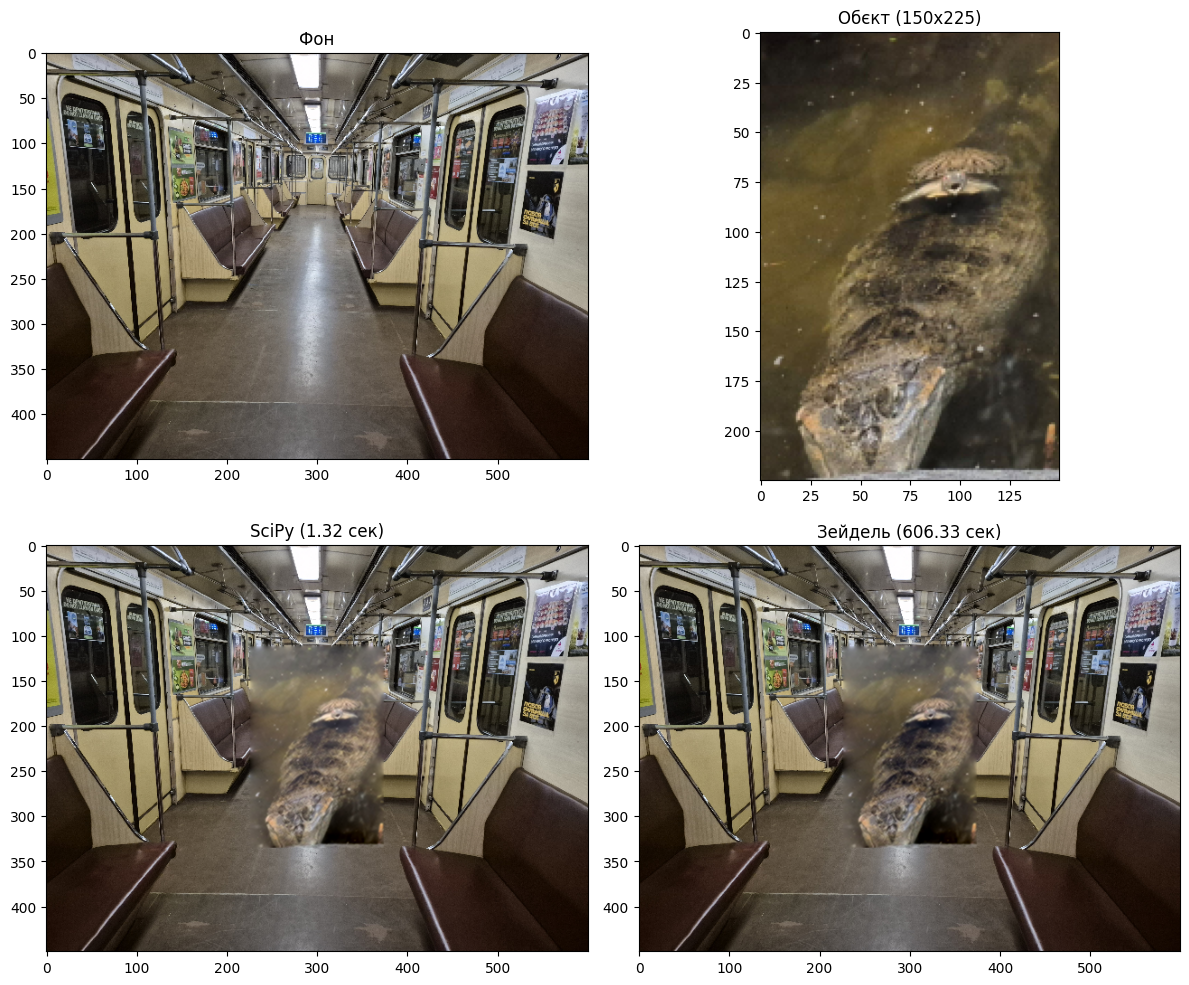

In [ ]:
scale_percent = 15
bg_width = int(img_orig.shape[1] * scale_percent / 100)
bg_height = int(img_orig.shape[0] * scale_percent / 100)
img_resized = cv2.resize(img_orig, (bg_width, bg_height))

patch_w, patch_h = 150, 225
source_small = cv2.resize(blend_orig, (patch_w, patch_h))

target_h, target_w = img_resized.shape[:2]
y_start = (target_h - patch_h) // 2
y_end = y_start + patch_h
x_start = (target_w - patch_w) // 2
x_end = x_start + patch_w
mask_region = (y_start, y_end, x_start, x_end)


start_scipy = time.time()
cloned_scipy = seamless_clone(img_resized, source_small, mask_region, method='scipy')
time_scipy = time.time() - start_scipy
print(f"Час SciPy: {time_scipy:.3f} сек")

start_seidel = time.time()
cloned_seidel = seamless_clone(img_resized, source_small, mask_region, method='seidel', max_iter=5000)
time_seidel = time.time() - start_seidel

print(f"Час SciPy: {time_scipy:.3f} сек")
print(f"Час Зейделя: {time_seidel:.3f} сек")


plt.figure(figsize=(12, 10))

plt.subplot(221), plt.imshow(img_resized), plt.title('Фон')
plt.subplot(222), plt.imshow(source_small), plt.title(f"Обєкт ({patch_w}x{patch_h})")
plt.subplot(223), plt.imshow(cloned_scipy), plt.title(f'SciPy ({time_scipy:.2f} сек)')
plt.subplot(224), plt.imshow(cloned_seidel), plt.title(f'Зейдель ({time_seidel:.2f} сек)')

plt.tight_layout()
plt.show()